In [1]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "-1"


In [4]:
import pandas as pd
import numpy as np

mains = pd.read_csv("Downloads/iawe_mains_raw.csv", index_col=0, parse_dates=True)
fridge = pd.read_csv("Downloads/iawe_fridge_raw.csv", index_col=0, parse_dates=True)



In [5]:
print(type(mains))
print(type(fridge))

print(mains.head())
print(fridge.head())


<class 'pandas.core.frame.DataFrame'>
<class 'pandas.core.frame.DataFrame'>
                               power
NaT                           active
2013-05-24 05:30:00+05:30  285.56702
2013-05-24 05:31:00+05:30  284.51364
2013-05-24 05:32:00+05:30  283.38278
2013-05-24 05:33:00+05:30  419.19235
                                power
NaT                            active
2013-06-07 05:30:00+05:30  0.15758333
2013-06-07 05:31:00+05:30  0.16056666
2013-06-07 05:32:00+05:30  0.15817021
2013-06-07 05:33:00+05:30    105.3328


In [6]:
# Remove the bad first row
mains = mains[mains.index.notna()]
fridge = fridge[fridge.index.notna()]


In [7]:
mains["power"] = pd.to_numeric(mains["power"], errors="coerce")
fridge["power"] = pd.to_numeric(fridge["power"], errors="coerce")


In [8]:
print(mains.dtypes)
print(fridge.dtypes)

print(mains.head())
print(fridge.head())


power    float64
dtype: object
power    float64
dtype: object
                               power
2013-05-24 05:30:00+05:30  285.56702
2013-05-24 05:31:00+05:30  284.51364
2013-05-24 05:32:00+05:30  283.38278
2013-05-24 05:33:00+05:30  419.19235
2013-05-24 05:34:00+05:30  418.72562
                                power
2013-06-07 05:30:00+05:30    0.157583
2013-06-07 05:31:00+05:30    0.160567
2013-06-07 05:32:00+05:30    0.158170
2013-06-07 05:33:00+05:30  105.332800
2013-06-07 05:34:00+05:30  120.265060


In [9]:
mains.index = pd.to_datetime(mains.index)
fridge.index = pd.to_datetime(fridge.index)


In [10]:
print(type(mains.index))
print(type(fridge.index))


<class 'pandas.core.indexes.datetimes.DatetimeIndex'>
<class 'pandas.core.indexes.datetimes.DatetimeIndex'>


In [12]:
data = mains.join(fridge, how="inner", lsuffix="_mains", rsuffix="_fridge")


In [13]:
data = data.rename(columns={
    "power_mains": "mains",
    "power_fridge": "fridge"
})


In [14]:
print(data.head())
print(data.tail())
print(data.shape)


                               mains      fridge
2013-06-07 05:30:00+05:30  325.20004    0.157583
2013-06-07 05:31:00+05:30  317.23148    0.160567
2013-06-07 05:32:00+05:30  350.84314    0.158170
2013-06-07 05:33:00+05:30  449.42746  105.332800
2013-06-07 05:34:00+05:30  443.80338  120.265060
                               mains     fridge
2013-08-05 20:59:00+05:30  507.93646  80.664314
2013-08-05 21:00:00+05:30  537.79830  80.552690
2013-08-05 21:01:00+05:30  636.55316  81.200645
2013-08-05 21:02:00+05:30  694.19507  81.839300
2013-08-05 21:03:00+05:30  711.74084  82.171936
(85894, 2)


In [15]:
from sklearn.preprocessing import MinMaxScaler

mains_scaler = MinMaxScaler()
fridge_scaler = MinMaxScaler()

data["mains_norm"] = mains_scaler.fit_transform(data[["mains"]])
data["fridge_norm"] = fridge_scaler.fit_transform(data[["fridge"]])


In [16]:
print(data[["mains_norm", "fridge_norm"]].describe())


         mains_norm   fridge_norm
count  82418.000000  82917.000000
mean       0.074389      0.271736
std        0.106212      0.207425
min        0.000000      0.000000
25%        0.026614      0.000407
50%        0.037016      0.361935
75%        0.054478      0.402672
max        1.000000      1.000000


In [17]:
import numpy as np

WINDOW = 60  # 60 minutes

def create_windows(mains, fridge, window):
    X, y = [], []
    for i in range(window, len(mains)):
        X.append(mains[i-window:i])
        y.append(fridge[i])
    return np.array(X), np.array(y)

X, y = create_windows(
    data["mains_norm"].values,
    data["fridge_norm"].values,
    WINDOW
)


In [18]:
print(X.shape)
print(y.shape)


(85834, 60)
(85834,)


In [19]:
X = X.reshape((X.shape[0], X.shape[1], 1))


In [20]:
print(X.shape)


(85834, 60, 1)


In [21]:
split_index = int(0.8 * len(X))

X_train = X[:split_index]
y_train = y[:split_index]

X_val = X[split_index:]
y_val = y[split_index:]


In [22]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)


(68667, 60, 1) (68667,)
(17167, 60, 1) (17167,)


In [23]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64, input_shape=(60, 1)),
    Dense(1)
])


2026-02-08 17:46:16.216413: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-08 17:46:16.269901: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-08 17:46:17.642649: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-08 17:46:18.071535: E external/local_xla/xla/stream_executor/cuda/cuda_p

In [24]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [25]:
model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)


In [26]:
history = model.fit(
    X_train,
    y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64
)


Epoch 1/10
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 48s 43ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 2/10
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 3/10
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 45s 42ms/step - loss: nan - mae: nan - val_loss: nan - val_mae: nan
Epoch 4/10
1073/1073 ━━━━━━━━━━━━━━━━━━━━ 0s 36ms/step - loss: nan - mae: nan

KeyboardInterrupt: 

In [27]:
print("NaNs in raw data:")
print(data.isna().sum())

print("\nAny infinite values?")
print(np.isinf(data[['mains_norm', 'fridge_norm']]).sum())


NaNs in raw data:
mains          3476
fridge         2977
mains_norm     3476
fridge_norm    2977
dtype: int64

Any infinite values?
mains_norm     0
fridge_norm    0
dtype: int64


In [ ]:
# SAVE THE MODEL AND SCALERS
model.save("fridge_nilm_lstm.keras")
print("Model saved as fridge_nilm_lstm.keras")

import joblib
joblib.dump(mains_scaler, "mains_scaler.pkl")
joblib.dump(fridge_scaler, "fridge_scaler.pkl")
print("Scalers saved as .pkl files")

ABOVE

In [9]:
import pandas as pd

mains = pd.read_csv("iawe_mains_raw.csv", index_col=0, parse_dates=True)
fridge = pd.read_csv("iawe_fridge_raw.csv", index_col=0, parse_dates=True)

mains.columns = ['mains']
fridge.columns = ['fridge']

data = pd.concat([mains, fridge], axis=1).dropna()


In [10]:
data.head

<bound method NDFrame.head of                                mains      fridge
2013-06-07 05:30:00+05:30  325.20004  0.15758333
2013-06-07 05:31:00+05:30  317.23148  0.16056666
2013-06-07 05:32:00+05:30  350.84314  0.15817021
2013-06-07 05:33:00+05:30  449.42746    105.3328
2013-06-07 05:34:00+05:30  443.80338   120.26506
...                              ...         ...
2013-08-05 21:00:00+05:30   537.7983    80.55269
2013-08-05 21:01:00+05:30  636.55316   81.200645
2013-08-05 21:02:00+05:30  694.19507     81.8393
2013-08-05 21:03:00+05:30  711.74084   82.171936
NaT                           active      active

[81156 rows x 2 columns]>

In [11]:
import pandas as pd

# Load CSVs
mains = pd.read_csv(
    "iawe_mains_raw.csv",
    index_col=0,
    parse_dates=True
)

fridge = pd.read_csv(
    "iawe_fridge_raw.csv",
    index_col=0,
    parse_dates=True
)

# Rename column (CSV has unnamed column)
mains.columns = ['mains']
fridge.columns = ['fridge']

# Align by timestamp
data = pd.concat([mains, fridge], axis=1)

# Keep only common timestamps
data = data.dropna()

data.head()



,mains,fridge
2013-06-07 05:30:00+05:30,325.20004,0.15758333
2013-06-07 05:31:00+05:30,317.23148,0.16056666
2013-06-07 05:32:00+05:30,350.84314,0.15817021
2013-06-07 05:33:00+05:30,449.42746,105.3328
2013-06-07 05:34:00+05:30,443.80338,120.26506


In [12]:
print(data.head())
print(data.dtypes)



                               mains      fridge
2013-06-07 05:30:00+05:30  325.20004  0.15758333
2013-06-07 05:31:00+05:30  317.23148  0.16056666
2013-06-07 05:32:00+05:30  350.84314  0.15817021
2013-06-07 05:33:00+05:30  449.42746    105.3328
2013-06-07 05:34:00+05:30  443.80338   120.26506
mains     object
fridge    object
dtype: object


In [13]:
data['mains'] = pd.to_numeric(data['mains'], errors='coerce')
data['fridge'] = pd.to_numeric(data['fridge'], errors='coerce')


In [14]:
data = data.dropna()


In [15]:
print(data.dtypes)


mains     float64
fridge    float64
dtype: object


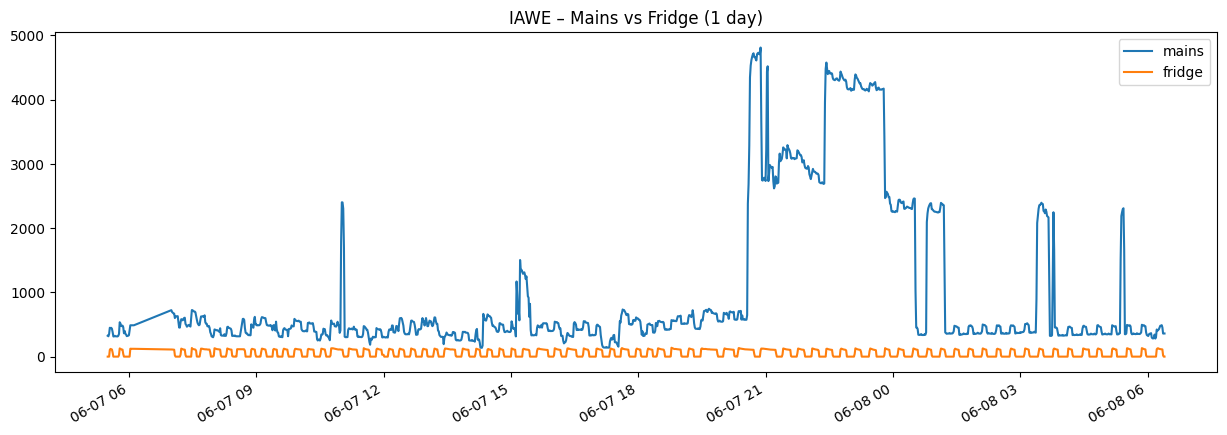

In [16]:
import matplotlib.pyplot as plt

data.iloc[:1440][['mains', 'fridge']].plot(figsize=(15,5))
plt.title("IAWE – Mains vs Fridge (1 day)")
plt.show()


In [17]:
from sklearn.preprocessing import MinMaxScaler

mains_scaler = MinMaxScaler()
fridge_scaler = MinMaxScaler()

data['mains_norm'] = mains_scaler.fit_transform(data[['mains']])
data['fridge_norm'] = fridge_scaler.fit_transform(data[['fridge']])


In [18]:
data[['mains_norm', 'fridge_norm']].head()


,mains_norm,fridge_norm
2013-06-07 05:30:00+05:30,0.026058,0.000338
2013-06-07 05:31:00+05:30,0.025119,0.000352
2013-06-07 05:32:00+05:30,0.029078,0.000341
2013-06-07 05:33:00+05:30,0.040688,0.477459
2013-06-07 05:34:00+05:30,0.040026,0.545198


In [19]:
data.isna().sum()


mains          0
fridge         0
mains_norm     0
fridge_norm    0
dtype: int64

In [20]:
import numpy as np

def create_windows(mains, fridge, window_size):
    X, y = [], []
    for i in range(len(mains) - window_size):
        X.append(mains[i:i+window_size])
        y.append(fridge[i+window_size])
    return np.array(X), np.array(y)


In [21]:
WINDOW = 60  # minutes

X, y = create_windows(
    data['mains_norm'].values,
    data['fridge_norm'].values,
    WINDOW
)


In [22]:
print(X.shape)
print(y.shape)


(81095, 60)
(81095,)


In [23]:
X = X.reshape((X.shape[0], X.shape[1], 1))


In [24]:
print(X.shape)


(81095, 60, 1)


In [25]:
split_index = int(0.8 * len(X))


In [26]:
X_train = X[:split_index]
X_val   = X[split_index:]

y_train = y[:split_index]
y_val   = y[split_index:]


In [27]:
print(X_train.shape, y_train.shape)
print(X_val.shape, y_val.shape)


(64876, 60, 1) (64876,)
(16219, 60, 1) (16219,)


In [28]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

model = Sequential([
    LSTM(64, input_shape=(60, 1)),
    Dense(1)
])


2026-02-08 15:35:35.713173: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-08 15:35:35.773090: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-08 15:35:37.072668: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-08 15:35:37.392184: E external/local_xla/xla/stream_executor/cuda/cuda_p

In [29]:
model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 64)             │        16,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 16,961 (66.25 KB)

 Trainable params: 16,961 (66.25 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


In [31]:
import tensorflow as tf
tf.config.list_physical_devices()


[PhysicalDevice(name='/physical_device:CPU:0', device_type='CPU')]

In [32]:
history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=10,
    batch_size=64
)


Epoch 1/10
1014/1014 ━━━━━━━━━━━━━━━━━━━━ 44s 42ms/step - loss: 0.0474 - mae: 0.2005 - val_loss: 0.0271 - val_mae: 0.1551
Epoch 2/10
1014/1014 ━━━━━━━━━━━━━━━━━━━━ 43s 42ms/step - loss: 0.0459 - mae: 0.1965 - val_loss: 0.0241 - val_mae: 0.1367
Epoch 3/10
1014/1014 ━━━━━━━━━━━━━━━━━━━━ 44s 44ms/step - loss: 0.0424 - mae: 0.1842 - val_loss: 0.0229 - val_mae: 0.1318
Epoch 4/10
1014/1014 ━━━━━━━━━━━━━━━━━━━━ 42s 41ms/step - loss: 0.0397 - mae: 0.1745 - val_loss: 0.0229 - val_mae: 0.1275
Epoch 5/10
1014/1014 ━━━━━━━━━━━━━━━━━━━━ 43s 43ms/step - loss: 0.0377 - mae: 0.1656 - val_loss: 0.0233 - val_mae: 0.1252
Epoch 6/10
1014/1014 ━━━━━━━━━━━━━━━━━━━━ 44s 44ms/step - loss: 0.0351 - mae: 0.1540 - val_loss: 0.0220 - val_mae: 0.1134
Epoch 7/10
1014/1014 ━━━━━━━━━━━━━━━━━━━━ 42s 41ms/step - loss: 0.0336 - mae: 0.1477 - val_loss: 0.0220 - val_mae: 0.1140
Epoch 8/10
1014/1014 ━━━━━━━━━━━━━━━━━━━━ 43s 43ms/step - loss: 0.0323 - mae: 0.1425 - val_loss: 0.0224 - val_mae: 0.1092
Epoch 9/10
1014/1014 ━━━

In [33]:
y_pred = model.predict(X_val)


507/507 ━━━━━━━━━━━━━━━━━━━━ 7s 13ms/step


In [34]:
print(y_pred.shape, y_val.shape)


(16219, 1) (16219,)


In [35]:
y_pred_watts = fridge_scaler.inverse_transform(y_pred)


In [36]:
y_val_watts = fridge_scaler.inverse_transform(
    y_val.reshape(-1, 1)
)


In [37]:
print(y_pred_watts[:5].flatten())
print(y_val_watts[:5].flatten())


[60.797626 61.54447  60.990944 60.00478  60.45798 ]
[0.16226315 0.17653489 0.17070213 0.16456896 0.17215517]


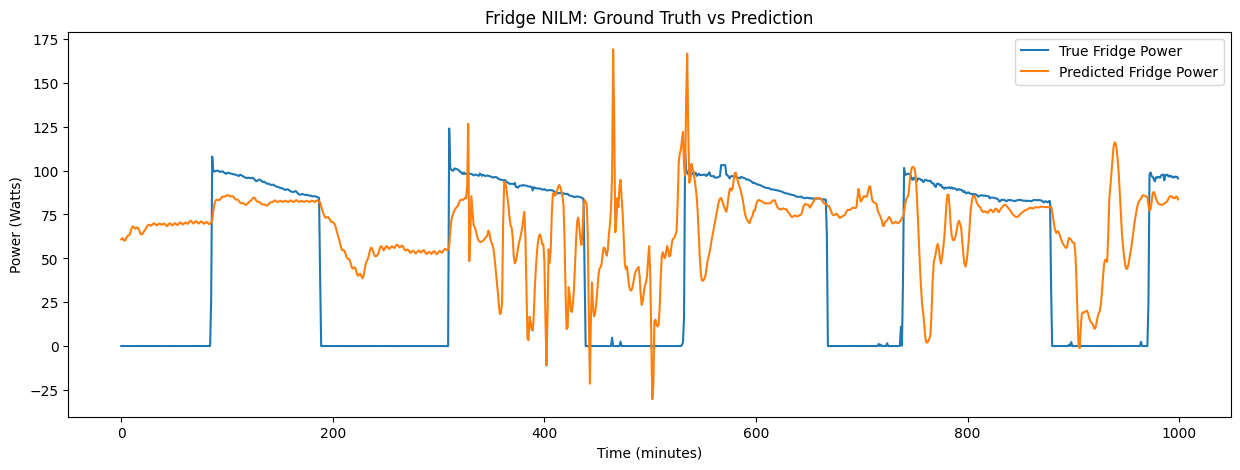

In [38]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15,5))

plt.plot(y_val_watts[:1000], label='True Fridge Power')
plt.plot(y_pred_watts[:1000], label='Predicted Fridge Power')

plt.legend()
plt.title("Fridge NILM: Ground Truth vs Prediction")
plt.xlabel("Time (minutes)")
plt.ylabel("Power (Watts)")

plt.show()


In [39]:
# Choose a threshold (start simple)
THRESHOLD = 30  # watts

y_pred_thresh = y_pred_watts.copy()
y_pred_thresh[y_pred_thresh < THRESHOLD] = 0


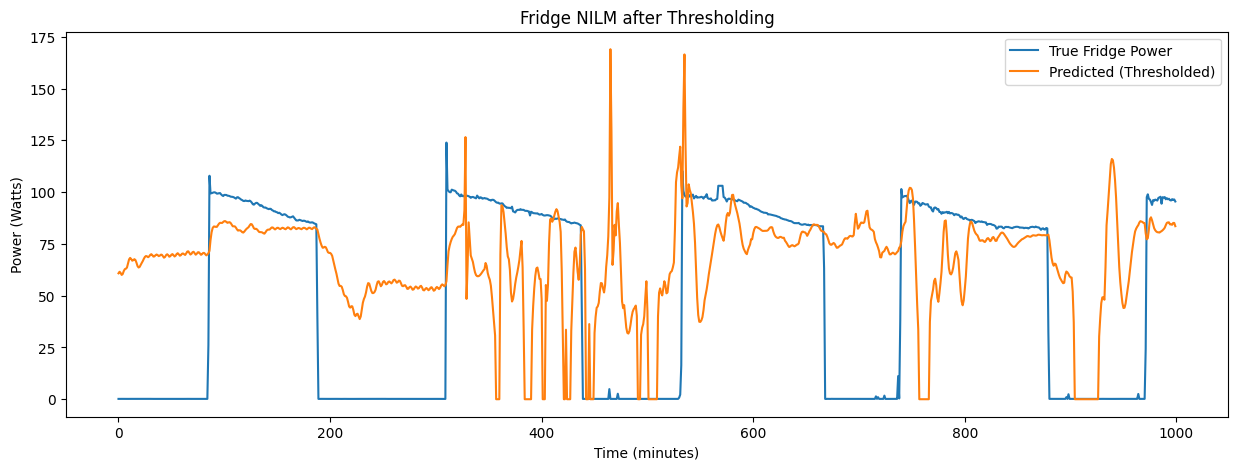

In [40]:
plt.figure(figsize=(15,5))

plt.plot(y_val_watts[:1000], label='True Fridge Power')
plt.plot(y_pred_thresh[:1000], label='Predicted (Thresholded)')

plt.legend()
plt.title("Fridge NILM after Thresholding")
plt.xlabel("Time (minutes)")
plt.ylabel("Power (Watts)")

plt.show()


In [41]:
import pandas as pd

# Convert to pandas Series
y_pred_series = pd.Series(y_pred_watts.flatten())


# Apply median smoothing (window = 5 minutes)
y_pred_smooth = y_pred_series.rolling(
    window=5,
    center=True
).median()

# Replace NaNs at edges
y_pred_smooth = y_pred_smooth.fillna(method='bfill').fillna(method='ffill')


/tmp/ipykernel_559539/2423543463.py:14: FutureWarning: Series.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  y_pred_smooth = y_pred_smooth.fillna(method='bfill').fillna(method='ffill')


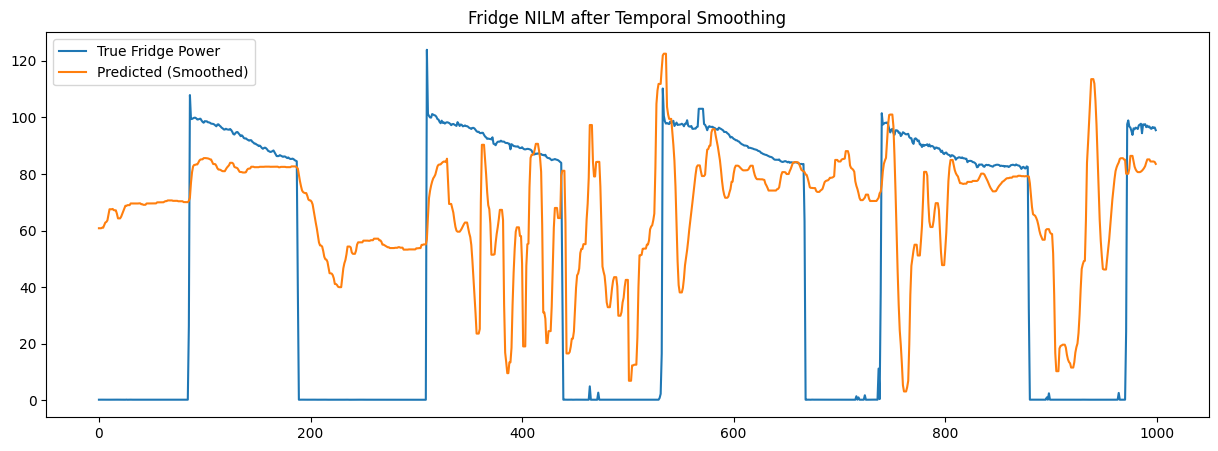

In [42]:
plt.figure(figsize=(15,5))
plt.plot(y_val_watts[:1000], label='True Fridge Power')
plt.plot(y_pred_smooth[:1000], label='Predicted (Smoothed)')
plt.legend()
plt.title("Fridge NILM after Temporal Smoothing")
plt.show()


In [43]:
# Threshold in watts (fridge ON ≈ >50W)
THRESHOLD = 50

y_true_on = (y_val_watts > THRESHOLD).astype(int)
y_pred_on = (y_pred_smooth.values > THRESHOLD).astype(int)


In [44]:
from sklearn.metrics import precision_score, recall_score, f1_score

precision = precision_score(y_true_on, y_pred_on)
recall = recall_score(y_true_on, y_pred_on)
f1 = f1_score(y_true_on, y_pred_on)

precision, recall, f1


(0.8196897118753128, 0.9208095735282307, 0.867312202133293)

In [46]:
true_energy = y_true.sum()
pred_energy = y_pred_smooth.sum()

sae = abs(pred_energy - true_energy) / true_energy
true_energy, pred_energy, sae


NameError: name 'y_true' is not defined

In [ ]:
true_energy = y_val_watts.sum()
pred_energy = y_pred_smooth.sum()

sae = abs(pred_energy - true_energy) / true_energy

true_energy, pred_energy, sae


NameError: name 'y_val_watts' is not defined

In [47]:
locals().keys()


dict_keys(['__name__', '__doc__', '__package__', '__loader__', '__spec__', '__builtin__', '__builtins__', '_ih', '_oh', '_dh', 'In', 'Out', 'get_ipython', 'exit', 'quit', 'open', '_', '__', '___', '__vsc_ipynb_file__', '_i', '_ii', '_iii', '_i1', 'ON_THRESHOLD', '_i2', '_2', '_i3', '_3', '_i4', '_i5', '_i6', '_i7', 'os', '_i8', '_i9', 'pd', 'mains', 'fridge', 'data', '_i10', '_10', '_i11', '_11', '_i12', '_i13', '_i14', '_i15', '_i16', 'plt', '_i17', 'MinMaxScaler', 'mains_scaler', 'fridge_scaler', '_i18', '_18', '_i19', '_19', '_i20', 'np', 'create_windows', '_i21', 'WINDOW', 'X', 'y', '_i22', '_i23', '_i24', '_i25', 'split_index', '_i26', 'X_train', 'X_val', 'y_train', 'y_val', '_i27', '_i28', 'Sequential', 'LSTM', 'Dense', 'model', '_i29', '_i30', '_i31', 'tf', '_31', '_i32', 'history', '_i33', 'y_pred', '_i34', '_i35', 'y_pred_watts', '_i36', 'y_val_watts', '_i37', '_i38', '_i39', 'THRESHOLD', 'y_pred_thresh', '_i40', '_i41', 'y_pred_series', 'y_pred_smooth', '_i42', '_i43', 'y_tru

In [48]:
ON_THRESHOLD = 10  # watts (fridge ON)
on_mask = (y_val_watts > ON_THRESHOLD).astype(float)


In [50]:
print(y_pred_smooth.shape)
print(on_mask.shape)


(16219,)
(16219, 1)


In [53]:
import numpy as np

y_pred_smooth = np.asarray(y_pred_smooth).reshape(-1)
on_mask = np.asarray(on_mask).reshape(-1)




In [54]:
y_pred_masked = y_pred_smooth * on_mask


In [55]:
y_pred_np = np.asarray(y_pred_smooth)
on_mask_np = np.asarray(on_mask)



In [56]:
y_pred_np = y_pred_np.reshape(-1)
on_mask_np = on_mask_np.reshape(-1)


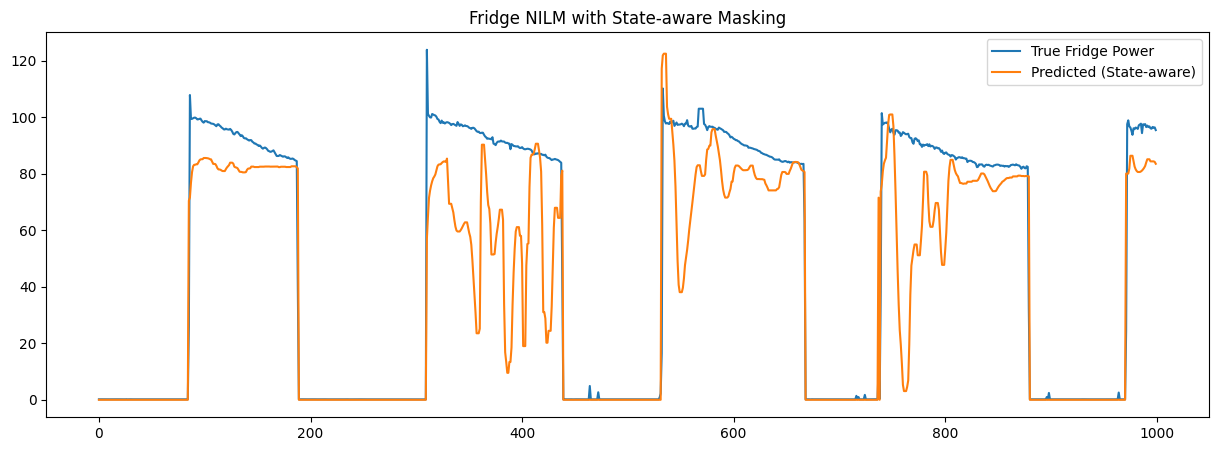

In [57]:
plt.figure(figsize=(15,5))
plt.plot(y_val_watts[:1000], label="True Fridge Power")
plt.plot(y_pred_masked[:1000], label="Predicted (State-aware)")
plt.legend()
plt.title("Fridge NILM with State-aware Masking")
plt.show()


In [58]:
# What happens in real world

In [59]:
# Take one test sample (one window)
sample_idx = 0

X_sample = X_val[sample_idx]   # shape: (60, 1)
y_true_sample = y_val[sample_idx]

print("X_sample shape:", X_sample.shape)
print("True fridge (normalized):", y_true_sample)


X_sample shape: (60, 1)
True fridge (normalized): 0.0003595722158893574


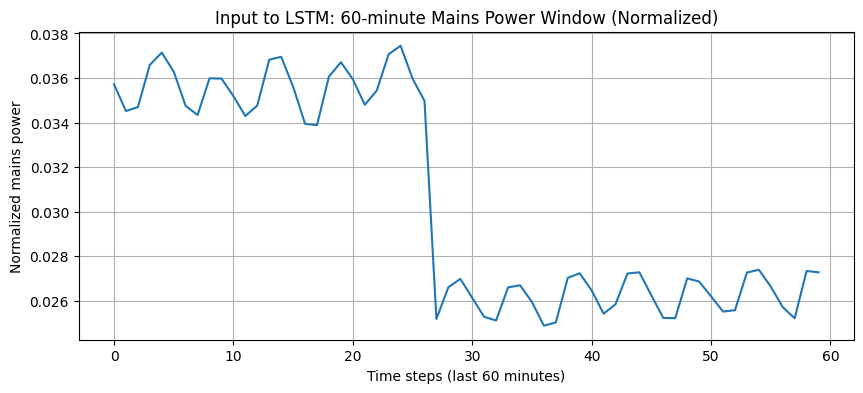

In [60]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))
plt.plot(X_sample.squeeze())
plt.title("Input to LSTM: 60-minute Mains Power Window (Normalized)")
plt.xlabel("Time steps (last 60 minutes)")
plt.ylabel("Normalized mains power")
plt.grid(True)
plt.show()


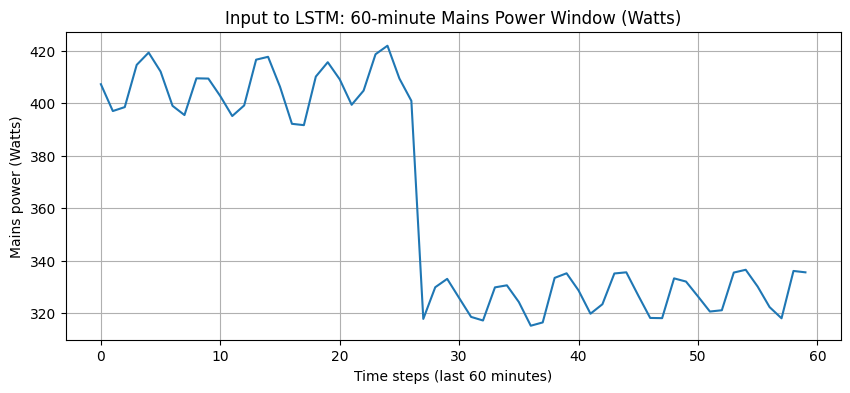

In [61]:
# Convert back to watts for interpretation
X_sample_watts = mains_scaler.inverse_transform(X_sample)

plt.figure(figsize=(10,4))
plt.plot(X_sample_watts.squeeze())
plt.title("Input to LSTM: 60-minute Mains Power Window (Watts)")
plt.xlabel("Time steps (last 60 minutes)")
plt.ylabel("Mains power (Watts)")
plt.grid(True)
plt.show()


In [62]:
# Model expects shape: (batch, timesteps, features)
X_input = X_sample.reshape(1, 60, 1)

# Predict (normalized)
y_pred_norm = model.predict(X_input)

# Convert prediction back to watts
y_pred_watts = fridge_scaler.inverse_transform(y_pred_norm)[0, 0]

# Ground truth (also convert to watts)
y_true_watts = fridge_scaler.inverse_transform(
    [[y_true_sample]]
)[0, 0]

print("Predicted fridge power (W):", y_pred_watts)
print("True fridge power (W):     ", y_true_watts)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Predicted fridge power (W): 60.797626
True fridge power (W):      0.16226315


In [63]:
print("True fridge (last 10 minutes):")
print(fridge_scaler.inverse_transform(
    y_val[-10:].reshape(-1,1)
).flatten())


True fridge (last 10 minutes):
[79.114075 78.77868  78.96308  79.78841  80.88884  80.664314 80.55269
 81.200645 81.8393   82.171936]


In [64]:
idx = 0  # same index everywhere

y_true_watts = fridge_scaler.inverse_transform(
    y_val[idx].reshape(1,1)
)[0,0]

print("True fridge power (W):", y_true_watts)


True fridge power (W): 0.16226315


In [65]:
off_idx = np.where(
    fridge_scaler.inverse_transform(y_val.reshape(-1,1)).flatten() < 5
)[0][0]

off_idx


np.int64(0)

In [66]:
on_idx = np.where(
    fridge_scaler.inverse_transform(y_val.reshape(-1,1)).flatten() > 50
)[0][0]

on_idx


np.int64(86)

In [67]:
def infer_at_index(idx):
    # input window
    X_win = X_val[idx].reshape(1, WINDOW, 1)

    # predict
    y_pred_norm = model.predict(X_win, verbose=0)
    y_pred_watts = fridge_scaler.inverse_transform(y_pred_norm)[0, 0]

    # true value
    y_true_watts = fridge_scaler.inverse_transform(
        y_val[idx].reshape(1,1)
    )[0,0]

    return y_pred_watts, y_true_watts


# OFF case
pred_off, true_off = infer_at_index(0)

# ON case
pred_on, true_on = infer_at_index(86)

print("OFF case  -> Predicted:", pred_off, "True:", true_off)
print("ON case   -> Predicted:", pred_on,  "True:", true_on)


OFF case  -> Predicted: 60.797626 True: 0.16226315
ON case   -> Predicted: 71.62391 True: 107.89583


In [68]:
def predict_fridge_from_mains(
    mains_window_watts,
    model,
    mains_scaler,
    fridge_scaler,
    threshold=50
):
    """
    mains_window_watts: array-like, shape (60,)
    returns: predicted fridge power in watts
    """

    # 1️⃣ Convert to numpy & reshape
    mains_window_watts = np.array(mains_window_watts).reshape(-1, 1)

    # 2️⃣ Scale mains input
    mains_scaled = mains_scaler.transform(mains_window_watts)

    # 3️⃣ Window shape for LSTM → (1, 60, 1)
    X_input = mains_scaled.reshape(1, 60, 1)

    # 4️⃣ Model prediction (normalized)
    fridge_pred_norm = model.predict(X_input, verbose=0)

    # 5️⃣ Inverse scale → watts
    fridge_pred_watts = fridge_scaler.inverse_transform(fridge_pred_norm)[0, 0]

    # 6️⃣ ON/OFF masking
    if fridge_pred_watts < threshold:
        fridge_pred_watts = 0.0

    return fridge_pred_watts


In [70]:
print(type(mains))
print(mains.head())


<class 'pandas.core.frame.DataFrame'>
                               mains
NaT                           active
2013-05-24 05:30:00+05:30  285.56702
2013-05-24 05:31:00+05:30  284.51364
2013-05-24 05:32:00+05:30  283.38278
2013-05-24 05:33:00+05:30  419.19235


In [71]:
# take any validation window

sample_mains_window = mains.values[100:160]


predicted = predict_fridge_from_mains(
    sample_mains_window,
    model,
    mains_scaler,
    fridge_scaler
)

print("Predicted fridge power (W):", predicted)


Predicted fridge power (W): nan


/home/jasil/miniconda3/envs/nilm-ml/lib/python3.10/site-packages/sklearn/utils/validation.py:2749: UserWarning: X does not have valid feature names, but MinMaxScaler was fitted with feature names
  warnings.warn(


In [72]:
print("Raw window stats:")
print("min:", np.min(sample_mains_window))
print("max:", np.max(sample_mains_window))
print("any NaN:", np.isnan(sample_mains_window).any())


Raw window stats:


TypeError: '<=' not supported between instances of 'str' and 'float'

In [73]:
print(type(sample_mains_window[0]))
print(sample_mains_window[:5])


<class 'numpy.ndarray'>
[['323.576']
 ['359.1479']
 ['324.06216']
 ['322.10547']
 ['323.34665']]
